# <center> Обучение с учителем. Классификация. Практика

## <center> Прогнозирование оттока клиентов банка

Для начала импортируем библиотеки, которые нам понадобятся:

In [1]:
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import model_selection #сплитование выборки
from sklearn import preprocessing #предобработка данных
%matplotlib inline


import plotly.express as px
from sklearn.preprocessing import StandardScaler

Итак, прочитаем нашу таблицу:

In [2]:
churn_data = pd.read_csv('churn.csv')
churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Признаки:
- RowNumber — номер строки таблицы;
- CustomerId — идентификатор клиента;
- Surname — фамилия клиента;
- CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их);
- Geography — страна проживания клиента (банк межнациональный);
- Gender — пол клиента;
- Age — возраст клиента;
- Tenure — сколько лет клиент пользуется банком;
- Balance — сколько у клиента денег на счетах в банке;
- NumOfProduct — число услуг банка, которыми воспользовался клиент;
- HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет);
- IsActiveMember — есть ли у клиента статус «активный клиент» (1 — да, 0 — нет);
- EstimatedSalary — предполагаемая заработная плата клиента;
- Exited — статус ушедшего (1 — ушедший клиент, 0 — лояльный клиент).

## Практика: логистическая регрессия

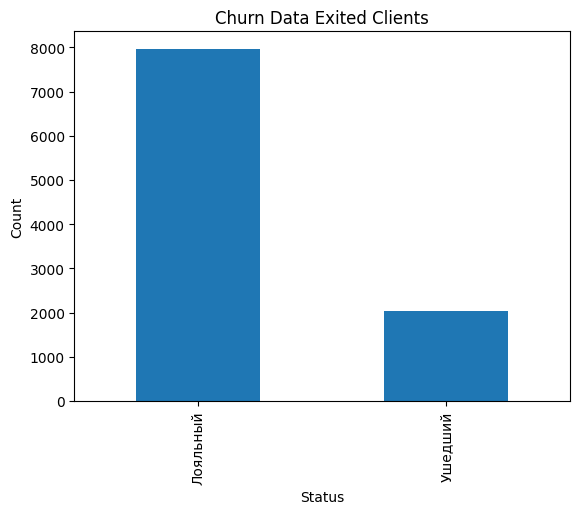

Exited
Лояльный    7963
Ушедший     2037
Name: count, dtype: int64


In [3]:
# Ваш код здесь

#преобразуем тип данных Exited 
churn_data['Exited'] = churn_data['Exited'].apply(lambda x: 'Лояльный' if x == 0 else 'Ушедший' )
counts_cl = churn_data['Exited'].value_counts()
counts_cl.plot(kind='bar')
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Churn Data Exited Clients')
plt.show()
print (counts_cl)

ВЫВОД По данной таблице можно сделать вывод о том, что количество лояльный клиентов превышает количество ушедших клиентов в 3,9 раза.

<Axes: xlabel='Balance', ylabel='Exited'>

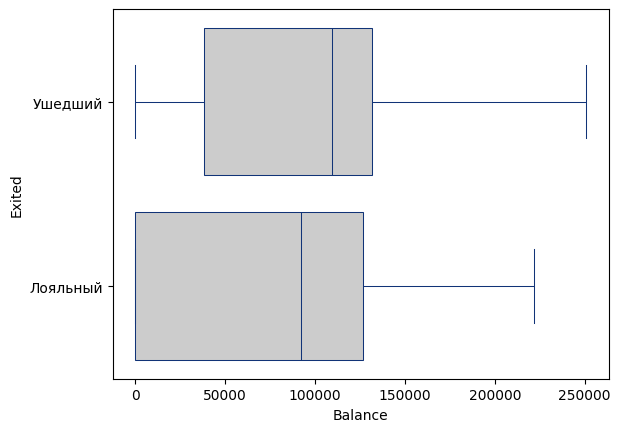

In [4]:
sns.boxplot(data=churn_data,x="Balance", y="Exited", color=".8", linecolor="#137", linewidth=.75) 


Text(0.5, 1.0, 'Распределение баланса ушедших пользователей')

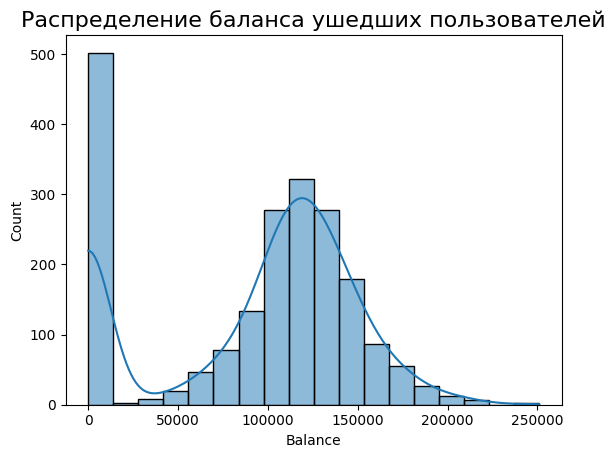

In [5]:
#выделяем строки с ушедшими клиентами
notloyal_clients = churn_data[churn_data['Exited'] == 'Ушедший'] 
#дополнительно строим гистограмму распределения, так как на ней хорошо видно большое количество клиентов с нулевым балансом
hst = sns.histplot(
        data=notloyal_clients,
        x='Balance',
        kde=True,
)
hst.set_title('Распределение баланса ушедших пользователей', fontsize=16)

ВЫВОД баланс ушедших клиентов больше, чем лояльных. Также среди ушедших клиентов большое количество клиентов с нулевым балансом.

<Axes: xlabel='Exited', ylabel='Age'>

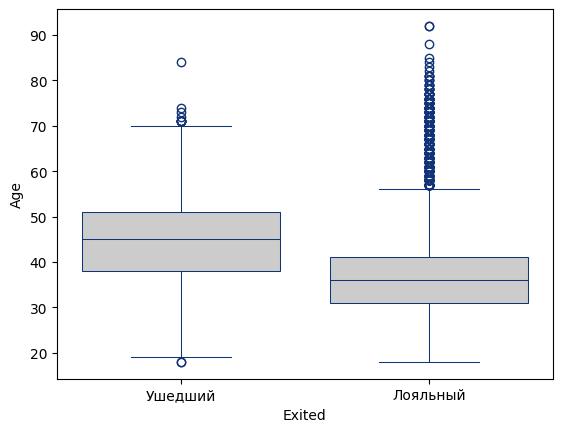

In [6]:
sns.boxplot(data=churn_data,x="Exited", y="Age", color=".8", linecolor="#137", linewidth=.75) 

ВЫВОД по графику можно сделать следующий: банку стоит обратить внимание на то, что возраст большинства ушедших клинетов от 40 до 50 лет. Также у клиентов старше 55 выбросов больше, это может говорить о том, что в этих возрастных группах лояльности меньше.

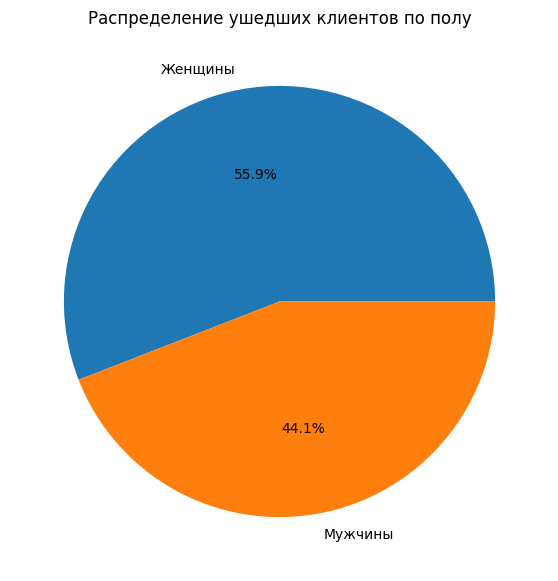

In [7]:
loyal_clients = churn_data[churn_data['Exited'] == 'Лояльный']
exited_clients = churn_data[churn_data['Exited'] == 'Ушедший']
fig2, axes2 = plt.subplots(figsize=(7, 7))
axes2.pie(
    exited_clients['Gender'].value_counts(),
    labels=['Женщины', 'Мужчины'],
    autopct='%.1f%%', 
)
axes2.set_title('Распределение ушедших клиентов по полу', fontsize=12);

ВЫВОД по этому графику: доля женщин среди ушедших клиентов выше.

Text(0, 0.5, 'Количество клиентов')

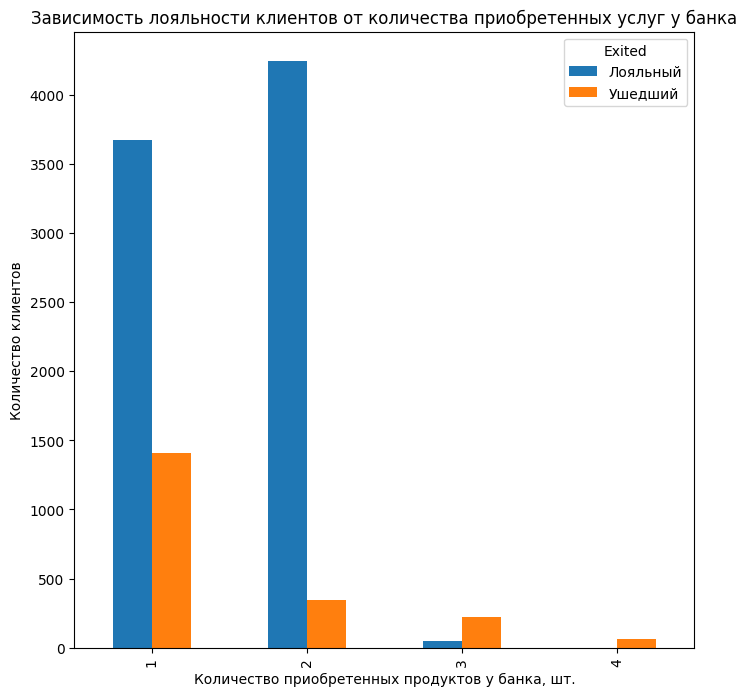

In [8]:
#выбираем данные
pivot3 = churn_data.pivot_table(
    'CustomerId',
    index='NumOfProducts',
    columns='Exited',
    aggfunc='count'
)
#замена пропусков на 0
pivot3 = pivot3.fillna(0) 
#строим диаграмму
fig3, axes3 = plt.subplots(figsize=(8, 8))
pivot3.plot(
    kind='bar',
    ax=axes3
)
axes3.set_title('Зависимость лояльности клиентов от количества приобретенных услуг у банка')
axes3.set_xlabel('Количество приобретенных продуктов у банка, шт.')
axes3.set_ylabel('Количество клиентов')

ВЫВОД по графику: явной завимости не наблюдается. Большая часть лояльных клиентов купили небольшое количество продуктов (1,2), но затем (3,4) количество лояльных клиентов резко снижается.
Количество ушедших клиентов снижается вместе с количеством купленных продуктов у банка.

Text(0, 0.5, 'Количество клиентов, чел')

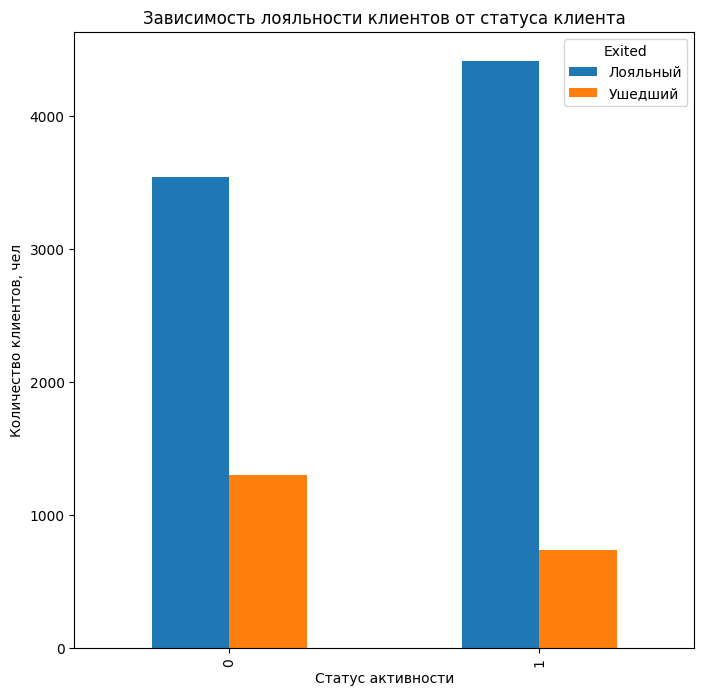

In [9]:
#выбираем данные
pivot4 = churn_data.pivot_table(
    'CustomerId',
    index='IsActiveMember',
    columns='Exited',
    aggfunc='count'
)
#замена пропусков на 0
pivot4 = pivot4.fillna(0) 
#строим диаграмму
fig4, axes4 = plt.subplots(figsize=(8, 8))
pivot4.plot(
    kind='bar',
    ax=axes4
)
axes4.set_title('Зависимость лояльности клиентов от статуса клиента')
axes4.set_xlabel('Статус активности')
axes4.set_ylabel('Количество клиентов, чел')

ВЫВОД по графику: 
1) доля ушедших неактивных клиентов выше, чем активных. И ,соответственно, активных лояльных клиентов больше, чем неактивных.
2) чтобы уменьшить отток неактивных клиентов, следует вовлекать неактивных клиентов в банковские услуги и предложения, вычислить причины оттока таких клиентов и устранить их, улучшать качество уже предоставляемых услуг. 

In [10]:
# преобразовываем признак лояльности обратно, для удобства подсчета
churn_data['Exited'] = churn_data['Exited'].apply(lambda x: 0 if x == 'Лояльный' else 1)
churn_countryes = churn_data.groupby(['Geography'])[['Exited']].mean()

fig5 = px.choropleth(
    data_frame=churn_countryes,
    locations=churn_countryes.index,
    locationmode = "country names",
    color="Exited",
    title='Доля ушедших клиентов по странам',
    width=800,
    height=500,
    range_color=[0, 0.5],
    color_continuous_scale='YlGnBu'
)
fig5.show()

ВЫВОД большая часть оттока клиентов приходится на Германию

ВЫВОД можно сделать о том, что большая часть ушедших клиентов с кредитным рейтингком Very_Poor и количеством лет меньше года.

In [ ]:
#выделим данные, которые относятся только к Германии
churn_data = churn_data[churn_data['Geography'] == 'Germany']
churn_data.shape

(2509, 14)

In [ ]:
#удалим неинформативные признаки
churn_data = churn_data.drop(['Geography', 'RowNumber', 'CustomerId', 'Surname'], axis=1)
churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,376,Female,29,4,115046.74,4,1,0,119346.88,1
15,616,Male,45,3,143129.41,2,0,1,64327.26,0
16,653,Male,58,1,132602.88,1,1,0,5097.67,1
26,756,Male,36,2,136815.64,1,1,1,170041.95,0
28,574,Female,43,3,141349.43,1,1,1,100187.43,0


Проверим, что в наших данных нет пропусков:

In [13]:
churn_data.isnull().sum()

CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Проверим, что в наших данных нет дубликатов:

In [14]:
churn_data[churn_data.duplicated()].sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance            0.0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary    0.0
Exited               0
dtype: object

In [ ]:
# создаем новые признаки
churn_data['BalanceSalaryRatio'] = churn_data['Balance'] / churn_data['EstimatedSalary']
churn_data['TenureByAge'] = churn_data['Tenure'] / churn_data['Age']
churn_data['CreditScoreGivenAge'] = churn_data['CreditScore'] / churn_data['Age']

churn_data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge
7,376,Female,29,4,115046.74,4,1,0,119346.88,1,0.963969,0.137931,12.965517
15,616,Male,45,3,143129.41,2,0,1,64327.26,0,2.225020,0.066667,13.688889
16,653,Male,58,1,132602.88,1,1,0,5097.67,1,26.012449,0.017241,11.258621
26,756,Male,36,2,136815.64,1,1,1,170041.95,0,0.804599,0.055556,21.000000
28,574,Female,43,3,141349.43,1,1,1,100187.43,0,1.410850,0.069767,13.348837


In [16]:
# кодируем оставшиеся текстовые признаки Gender и Exited

dummies_data = pd.get_dummies(churn_data, drop_first=True,dtype=int)
dummies_data.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Male
7,376,29,4,115046.74,4,1,0,119346.88,1,0.963969,0.137931,12.965517,0
15,616,45,3,143129.41,2,0,1,64327.26,0,2.225020,0.066667,13.688889,1
16,653,58,1,132602.88,1,1,0,5097.67,1,26.012449,0.017241,11.258621,1
26,756,36,2,136815.64,1,1,1,170041.95,0,0.804599,0.055556,21.000000,1
28,574,43,3,141349.43,1,1,1,100187.43,0,1.410850,0.069767,13.348837,0


In [17]:
dummies_data.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,TenureByAge,CreditScoreGivenAge,Gender_Male
count,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.00000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000
mean,651.453567,39.771622,5.009964,119730.116134,1.519729,0.71383,0.497409,101113.435102,0.324432,9.024870,0.134303,17.526487,0.524512
std,98.168937,10.519143,2.935154,27022.006157,0.619420,0.45206,0.500093,58263.011501,0.468256,214.286020,0.087680,5.349558,0.499498
min,350.000000,18.000000,0.000000,27288.430000,1.000000,0.00000,0.000000,11.580000,0.000000,0.192582,0.000000,6.112676,0.000000
25%,584.000000,32.000000,2.000000,102800.720000,1.000000,0.00000,0.000000,51016.020000,0.000000,0.783284,0.060606,13.686275,0.000000
50%,651.000000,38.000000,5.000000,119703.100000,1.000000,1.00000,0.000000,102397.220000,0.000000,1.197220,0.125000,16.857143,1.000000
75%,722.000000,45.000000,8.000000,137560.380000,2.000000,1.00000,1.000000,151083.800000,1.000000,2.400083,0.200000,20.852941,1.000000
max,850.000000,84.000000,10.000000,214346.960000,4.000000,1.00000,1.000000,199970.740000,1.000000,10614.655440,0.500000,46.388889,1.000000


Разделим исходный набор данных на матрицу наблюдений `X` (фичи) и столбец ответов `y` (таргет). 

In [18]:
X = dummies_data.drop("Exited", axis=1)
y = dummies_data["Exited"]

In [ ]:
#посмотрим на сбалансированность данных
y.value_counts(normalize=True)

Exited
0    0.675568
1    0.324432
Name: proportion, dtype: float64

Очевидно, что классы не сбалансированы. Ушедших пользователей 32 %, в то время как лояльных — 68 %.


In [ ]:
#разделим наши данные на тренировочные и тестовые
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Проверим, что число лояльных и ушедших клиентов примерно одинаково в каждой из выборок:

In [21]:
print('Train :')
display(y_train.value_counts(normalize=True))
print('\n')
print('Test :', )
display(y_test.value_counts(normalize=True))

Train :


Exited
0    0.675704
1    0.324296
Name: proportion, dtype: float64



Test :


Exited
0    0.675159
1    0.324841
Name: proportion, dtype: float64

Соотношения одинаковы, а значит, мы можем перейти к следующему шагу.

In [ ]:
#выбиираем StandarsScaler так как данные распределены нормально, и данный метод более подходит для линейных моделей
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

Теперь переходим к моделированию.

In [ ]:
#Создаем объект класса логистическая регрессия
log_reg = linear_model.LogisticRegression(
    solver='sag', #алгоритм оптимизации
    random_state=42, #генератор случайных чисел
    max_iter=1000 #количество итераций на сходимость
)
#Обучаем модель, минимизируя logloss
log_reg.fit(X_train_scaled, y_train)


#Делаем предсказание для тренировочной выборки
y_train_pred = log_reg.predict(X_train_scaled)
#Рассчитываем F1-меру для тренировочной выборки
print('F1 train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))

#Делаем предсказание для тестовой выборки
y_test_pred = log_reg.predict(X_test_scaled)
#Рассчитываем F1-меру для тестовой выборки
print('F1 test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

F1 train: 0.51
F1 test: 0.49


In [24]:
# меняем параметры penalty на L1, так как L2 стоит по умолчанию
log_reg_L1 = linear_model.LogisticRegression(
    penalty='l1',
    solver='saga', 
    random_state=42,
    max_iter=1000 
)
#Обучаем модель, минимизируя logloss
log_reg_L1.fit(X_train_scaled, y_train)


#Делаем предсказание для тренировочной выборки
y_train_pred_L1 = log_reg_L1.predict(X_train_scaled)
#Рассчитываем F1-меру для тренировочной выборки
print('F1 train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred_L1)))

#Делаем предсказание для тестовой выборки
y_test_pred_L1 = log_reg_L1.predict(X_test_scaled)
#Рассчитываем F1-меру для тестовой выборки
print('F1 test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred_L1)))

F1 train: 0.52
F1 test: 0.50


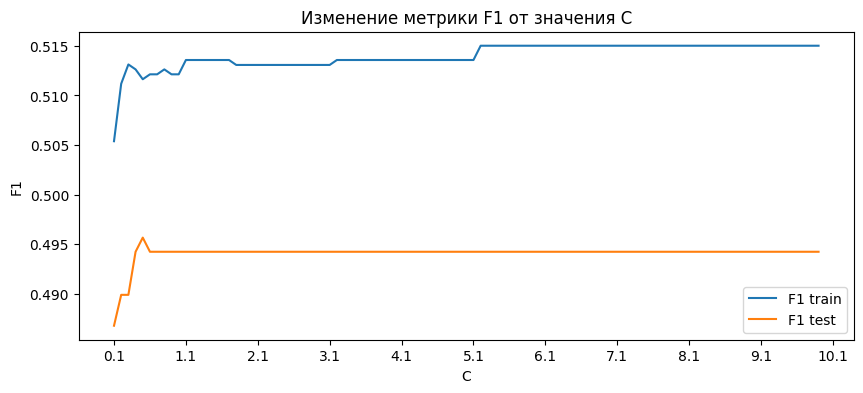

In [25]:
#изменение параметра C
#создадим массив числе от 0.1 до 1 с шагом 0.1
C_array = np.arange(0.1, 10, 0.1)
#создадим списки для подсчета для тренировочной и тестовой выборок
c_train = []
c_test = []
#создаем цикл, в котором будем изменять значения С с указанным шагом
for C in C_array:
    log_reg_C = linear_model.LogisticRegression(
        solver ='sag',
        random_state = 42,
        max_iter= 1000,
        C=C
    )
    #Обучаем модель, минимизируя logloss
    log_reg_C.fit(X_train_scaled, y_train)
    #Делаем предсказание для тренировочной выборки
    y_train_pred_C = log_reg_C.predict(X_train_scaled)
    #Рассчитываем F1-меру для тренировочной выборки
    c_train.append(metrics.f1_score(y_train, y_train_pred_C))

    #Делаем предсказание для тестовой выборки
    y_test_pred_C = log_reg_C.predict(X_test_scaled)
    #Рассчитываем F1-меру для тестовой выборки
    c_test.append(metrics.f1_score(y_test, y_test_pred_C))

#визуализируем полученные данные для удобства
fig, ax = plt.subplots(figsize = (10,4))

#строим график изменения метрики F1 от параметра С
ax.plot(C_array, c_train, label = 'F1 train')
ax.plot(C_array, c_test, label = 'F1 test')

ax.set_title('Изменение метрики F1 от значения C')
ax.set_xlabel('C')
ax.set_ylabel('F1')
ax.set_xticks(np.arange(min(C_array), max(C_array)+1, 1))
ax.legend()
plt.show()

In [ ]:
#создадим генератор полиномиальных признаков
poly_create = preprocessing.PolynomialFeatures(degree=3,include_bias=False)
poly_create.fit(X_train_scaled)
#сгенерируем полиномиальные признаки для тренировочной выборки
X_train_scaled_poly = poly_create.transform(X_train_scaled)
#для тестовой выборки
X_test_scaled_poly = poly_create.transform(X_test_scaled)
#выведем размеры таблиц
print(X_train_scaled_poly.shape)
print(X_test_scaled_poly.shape)

(1881, 454)
(628, 454)


In [27]:
#масштабируем данные
scaler = StandardScaler()
X_train_scaled_poly = scaler.fit_transform(X_train_scaled_poly)
X_test_scaled_poly = scaler.transform(X_test_scaled_poly)

log_reg = linear_model.LogisticRegression(
    solver='sag', #алгоритм оптимизации
    random_state=42, #генератор случайных чисел
    max_iter=10000 #количество итераций на сходимость
)
#приступаем к обучению модели
log_reg.fit(X_train_scaled_poly, y_train)

#делаем предсказание для тренировочной выборки 
y_train_pred_poly = log_reg.predict(X_train_scaled_poly)
#рассчитываем F1метрику для тренировочной выборки
print('F1 train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred_poly)))

#делаем предсказание для тестовой выборки
y_test_pred_poly = log_reg.predict(X_test_scaled_poly)
#рассчитываем метрику F1 для тестовой выборки
print('F1 test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred_poly)))

F1 train: 0.76
F1 test: 0.66


In [28]:
#меняем параметры penalty на L1, так как L2 стоит по умолчанию
log_reg_L1 = linear_model.LogisticRegression(
    penalty='l1',
    solver='saga', 
    random_state=42,
    max_iter=10000 
)
#Обучаем модель, минимизируя logloss
log_reg_L1.fit(X_train_scaled_poly, y_train)


#Делаем предсказание для тренировочной выборки
y_train_pred_L1_poly = log_reg_L1.predict(X_train_scaled_poly)
#Рассчитываем F1-меру для тренировочной выборки
print('F1 train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred_L1_poly)))

#Делаем предсказание для тестовой выборки
y_test_pred_L1_poly = log_reg_L1.predict(X_test_scaled_poly)
#Рассчитываем F1-меру для тестовой выборки
print('F1 test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred_L1_poly)))

F1 train: 0.76
F1 test: 0.66


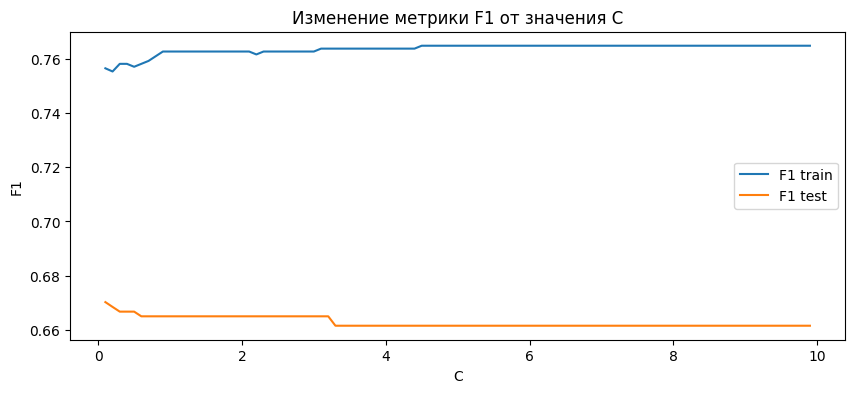

In [29]:
#изменение параметра C
C_array = np.arange(0.1, 10, 0.1)
c_train = []
c_test = []
for C in C_array:
    log_reg = linear_model.LogisticRegression(
        solver ='sag',
        random_state = 42,
        max_iter= 3000,
        C=C
    )
    #Обучаем модель, минимизируя logloss
    log_reg.fit(X_train_scaled_poly, y_train)
    #Делаем предсказание для тренировочной выборки
    y_train_pred_C_poly = log_reg.predict(X_train_scaled_poly)
    #Рассчитываем F1-меру для тренировочной выборки
    c_train.append(metrics.f1_score(y_train, y_train_pred_C_poly))

    #Делаем предсказание для тестовой выборки
    y_test_pred_C_poly = log_reg.predict(X_test_scaled_poly)
    #Рассчитываем F1-меру для тестовой выборки
    c_test.append(metrics.f1_score(y_test, y_test_pred_C_poly))

#визуализируем полученные данные для удобства
fig, ax = plt.subplots(figsize = (10,4))

#строим график изменения метрики F1 от параметра С
ax.plot(C_array, c_train, label = 'F1 train')
ax.plot(C_array, c_test, label = 'F1 test')

ax.set_title('Изменение метрики F1 от значения C')
ax.set_xlabel('C')
ax.set_ylabel('F1')
ax.legend()

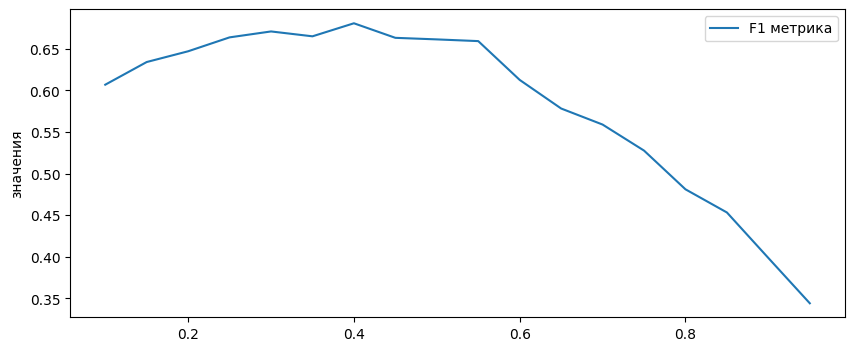

In [ ]:
# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(log_reg.predict_proba(X_test_scaled_poly)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
f1_score = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_poly = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    
    # Рассчитываем метрики и добавляем результат в список
    f1_score.append(metrics.f1_score(y_test, y_test_pred_poly))
   
    
#строим график зависимости метрики F1 от thresholds
fig, ax = plt.subplots(figsize=(10, 4)) 

ax.plot(thresholds, f1_score, label='F1 метрика')
ax.set_ylabel('значения')
ax.legend();

## Деревья решений и случайный лес

In [31]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    stratify=y, 
    random_state=0
)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (1881, 12)
Test shape: (628, 12)


Импортируем необходимые для выполнения практики модули:

In [32]:
from sklearn import tree
from sklearn import ensemble

In [ ]:
#Создаём объект класса DecisionTreeClassifier
tr = tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
#Обучаем дерево по алгоритму CART
tr.fit(X_train, y_train)
#Выводим значения метрики 
y_train_pred_tree = tr.predict(X_train)
print('F1 score Train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred_tree)))
y_test_pred_tree = tr.predict(X_test)
print('F1 score Test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred_tree)))

F1 score Train: 1.00
F1 score Test: 0.53


Модель переобучена, так как на тренировочной выборке метрика F1 = 1, а на тестовой гораздо ниже = 0.53.
Это произошло, потому что не установлена максимальная глубина дерева и минимальное число объектов в листе.

In [ ]:
#используем дополнительные параметры
#Создаём объект класса DecisionTreeClassifier
tr2 = tree.DecisionTreeClassifier(
    criterion='entropy',
    min_samples_leaf=10,
    max_depth=8,
    random_state=42
)
#Обучаем дерево по алгоритму CART
tr2.fit(X_train, y_train)
#Выводим значения метрики 
y_train_pred_tree2 = tr2.predict(X_train)
print('F1 score Train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred_tree2)))
y_test_pred_tree2 = tr2.predict(X_test)
print('F1 score Test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred_tree2)))

F1 score Train: 0.72
F1 score Test: 0.65


 Метрики стали гораздо лучше, за счет использования дополнительных параметров.

In [ ]:
#строим модель RandomForest
#Создаем объект класса случайный лес
tr3 = ensemble.RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    criterion='entropy',
    min_samples_leaf=10,
    random_state=42
)
#Обучаем модель
tr3.fit(X_train, y_train)
#Выводим значения метрики 
y_train_pred3 = tr3.predict(X_train)
print('Train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred3)))
y_test_pred3 = tr3.predict(X_test)
print('Test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred3)))

Train: 0.73
Test: 0.64


Использование случайного леса не привело к значительным изменениям. Метрика F1 для тестовой выборки стала даже меньше - 0.64(была 0.65)

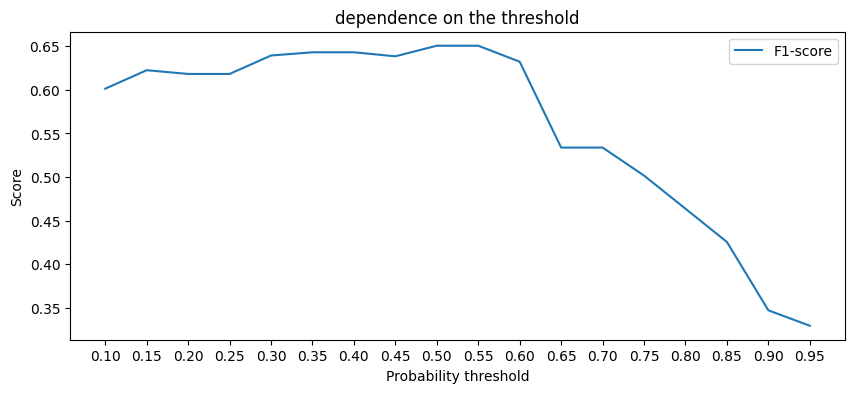

In [ ]:
# Подбираем порог вероятности

# Делаем предсказание вероятности оттока для каждого клиента из тестовой выборки
y_test_proba_pred = pd.Series(tr2.predict_proba(X_test)[:, 1])
# Инициализируем список, куда будем сохранять метрики.
scores = []
# Задаём значения порогов вероятности
thresholds = np.arange(0.1, 1, 0.05)
# В цикле перебираем значения порогов вероятности
for threshold in thresholds:
    # Делаем предсказание
    y_test_pred_tree2 = y_test_proba_pred.apply(lambda x: 1 if x > threshold else 0)
    #Считаем метрику и добавляем в список
    scores.append(metrics.f1_score(y_test, y_test_pred_tree2))

#Визуализируем метрику при различных threshold
fig, ax = plt.subplots(figsize=(10, 4)) #фигура + координатная плоскость
#Строим линейный график зависимости F1 от threshold
ax.plot(thresholds, scores, label='F1-score')
#Даем графику название и подписи осям
ax.set_title('dependence on the threshold')
ax.set_xlabel('Probability threshold')
ax.set_ylabel('Score')
ax.set_xticks(thresholds)
ax.legend();

In [49]:
#Задаем оптимальный порог вероятностей
threshold_opt = 0.55
y_test_pred_opt = y_test_proba_pred.apply(lambda x: 1 if x > threshold_opt else 0)
#Считаем метрики
print(metrics.classification_report(y_test, y_test_pred_opt))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       424
           1       0.72      0.59      0.65       204

    accuracy                           0.79       628
   macro avg       0.77      0.74      0.75       628
weighted avg       0.79      0.79      0.79       628



подбор оптимального порога вероятности не привел к улучшению метрики.

### Финальная задача.

У нашего банка есть некоторый клиент, назовём его Василием. В базе данных банка хранятся следующие данные о Василии:

```python
{
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
}
```

С помощью наилучшей модели спрогнозируйте вероятность того, что Василий откажется от услуг банка.


In [ ]:
new_client =pd.DataFrame({
    'CreditScore': [601.0],
    'Gender': ['Male'],
    'Age': [42.0],
    'Tenure': [1.0],
    'Balance': [98495.72],
    'NumOfProducts': [1.0],
    'HasCrCard': [1.0],
    'IsActiveMember': [0.0],
    'EstimatedSalary': [40014.76]
})
#создаем новые признаки
new_client['BalanceSalaryRatio'] = new_client['Balance'] / new_client['EstimatedSalary']
new_client['TenureByAge'] = new_client['Tenure'] / new_client['Age']
new_client['CreditScoreGivenAge'] = new_client['CreditScore'] / new_client['Age']

#кодируем новые признаки
new_client = pd.get_dummies(new_client, dtype=int)
#подем данные в модель
new_client_pred = tr2.predict(new_client)
new_client_pred_proba = tr2.predict_proba(new_client)

if new_client_pred == 1:
    display(f'Exited = {new_client_pred}. Потенциально уйдет из банка с вероятностью {new_client_pred_proba[0][1]:.2f}%')
else:
    display(f'Exited = {new_client_pred}. Потенциально останется клиентом банка с вероятностью {new_client_pred_proba[0][0]:.2f}%')


'Exited = [1]. Потенциально уйдет из банка с вероятностью 0.80%'